In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import pandas as pd

# Load your data
df = pd.read_csv('15_9-F-1A.LAS.csv')

# Prepare features
X = df[['Gamma_Ray', 'Porosity', 'Density', 'Neutron']]
y = df['Permeability']

# Split & Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train_scaled, y_train)

# Evaluate
y_pred = model.predict(X_test_scaled)
print(f"R² = {r2_score(y_test, y_pred):.4f}")

# Predict
new_well = scaler.transform([[50, 20, 2.4, 22]])
print(f"Predicted Perm = {model.predict(new_well)[0]:.2f} mD")

In [ ]:
# ============================================
# K-MEANS CLUSTERING FOR GEOSCIENCE DATA
# Simple Beginner Example
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("=" * 60)
print("K-MEANS CLUSTERING FOR GEOSCIENCE DATA")
print("=" * 60)

K-MEANS CLUSTERING FOR GEOSCIENCE DATA


In [ ]:
# --------------------------------------------
# STEP 1: CREATE SAMPLE WELL LOG DATA
# --------------------------------------------
print("\n[STEP 1] Creating Sample Well Log Data...")

# Simulate well log measurements (100 depth points)
np.random.seed(42)

data = {
    'Depth': np.linspace(2500, 2600, 100),
    'Gamma_Ray': np.random.normal(70, 30, 100).clip(20, 150),
    'Porosity': np.random.normal(20, 8, 100).clip(5, 35),
    'Density': np.random.normal(2.5, 0.4, 100).clip(1.8, 3.0)
}

# Add some structure (3 rock types)
data['Gamma_Ray'][:33] = np.random.normal(90, 15, 33)   # Shale (high GR)
data['Gamma_Ray'][33:66] = np.random.normal(50, 15, 33)  # Sandstone (low GR)
data['Gamma_Ray'][66:] = np.random.normal(70, 15, 34)    # Limestone (medium GR)

data['Porosity'][:33] = np.random.normal(10, 5, 33)      # Shale (low porosity)
data['Porosity'][33:66] = np.random.normal(25, 5, 33)    # Sandstone (high porosity)
data['Porosity'][66:] = np.random.normal(18, 5, 34)      # Limestone (medium porosity)

df = pd.DataFrame(data)
print(f"✓ Created {len(df)} depth points with 3 log measurements")
print(df.head())



[STEP 1] Creating Sample Well Log Data...
✓ Created 100 depth points with 3 log measurements
         Depth   Gamma_Ray   Porosity   Density
0  2500.000000   77.565075   2.027862  2.643115
1  2501.010101   81.597284   7.003125  2.724314
2  2502.020202  101.209404  10.026218  2.933220
3  2503.030303   99.155554  10.234903  2.921521
4  2504.040404   89.686476   7.749673  1.948932


In [ ]:
# --------------------------------------------
# STEP 2: PREPARE DATA FOR K-MEANS
# --------------------------------------------
print("\n[STEP 2] Preparing Data for K-Means...")

# Select features for clustering
features = ['Gamma_Ray', 'Porosity', 'Density']
X = df[features].values

print(f"Features used: {features}")
print(f"Data shape: {X.shape}")

# Scale the data (important for K-Means!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("✓ Data scaled (mean=0, std=1)")


[STEP 2] Preparing Data for K-Means...
Features used: ['Gamma_Ray', 'Porosity', 'Density']
Data shape: (100, 3)
✓ Data scaled (mean=0, std=1)


In [ ]:

# --------------------------------------------
# STEP 3: APPLY K-MEANS CLUSTERING
# --------------------------------------------
print("\n[STEP 3] Applying K-Means Clustering...")

# Choose number of clusters (we expect 3 rock types)
n_clusters = 3

# Create and fit the model
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"✓ K-Means completed with {n_clusters} clusters")
print(f"\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())


[STEP 3] Applying K-Means Clustering...
✓ K-Means completed with 3 clusters

Cluster distribution:
Cluster
0    37
1    31
2    32
Name: count, dtype: int64


In [ ]:
# --------------------------------------------
# STEP 4: ANALYZE CLUSTER CHARACTERISTICS
# --------------------------------------------
print("\n[STEP 4] Cluster Characteristics...")

cluster_summary = df.groupby('Cluster')[features].mean()
print(f"Average values per cluster:\n{cluster_summary}")


[STEP 4] Cluster Characteristics...
Average values per cluster:
         Gamma_Ray   Porosity   Density
Cluster                                
0        93.000689   9.919080  2.553088
1        56.334489  22.664506  2.151759
2        61.652048  20.918504  2.786185



[STEP 5] Creating Visualizations...


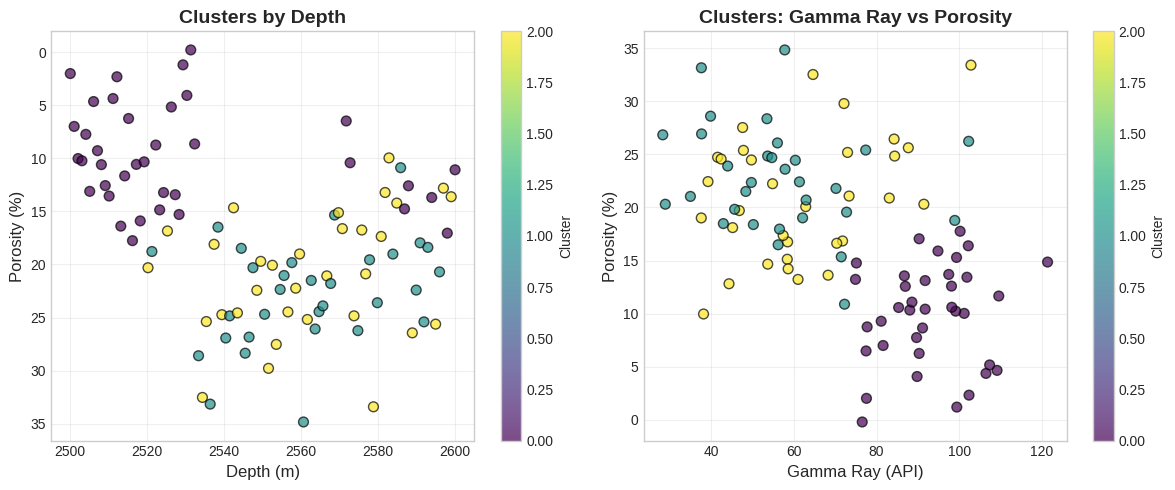

✓ Saved: kmeans_geoscience.png


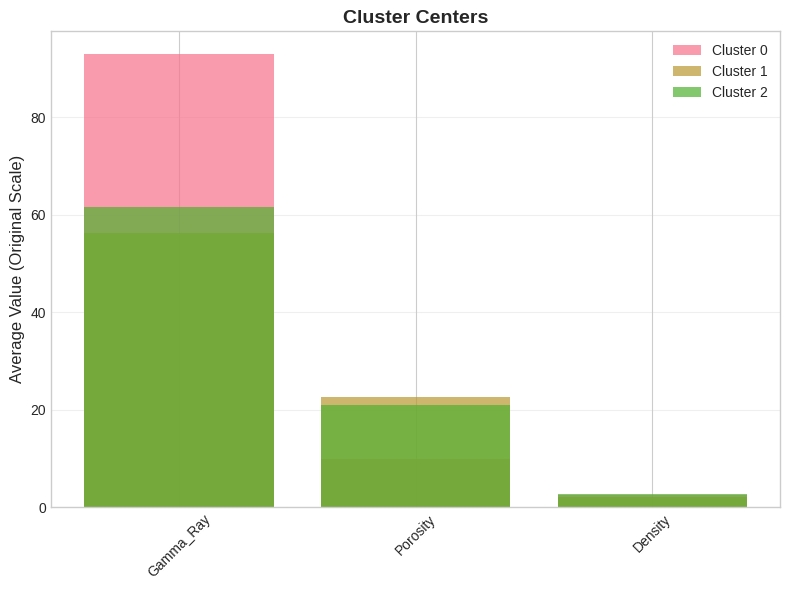

✓ Saved: kmeans_centers.png


In [ ]:
# --------------------------------------------
# STEP 5: VISUALIZE RESULTS
# --------------------------------------------
print("\n[STEP 5] Creating Visualizations...")

# Plot 1: Clusters by Depth
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
scatter = plt.scatter(df['Depth'], df['Porosity'],
                      c=df['Cluster'], cmap='viridis',
                      s=50, alpha=0.7, edgecolors='black')
plt.xlabel('Depth (m)', fontsize=12)
plt.ylabel('Porosity (%)', fontsize=12)
plt.title('Clusters by Depth', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Depth increases downward
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)

# Plot 2: Gamma Ray vs Porosity
plt.subplot(1, 2, 2)
scatter = plt.scatter(df['Gamma_Ray'], df['Porosity'],
                      c=df['Cluster'], cmap='viridis',
                      s=50, alpha=0.7, edgecolors='black')
plt.xlabel('Gamma Ray (API)', fontsize=12)
plt.ylabel('Porosity (%)', fontsize=12)
plt.title('Clusters: Gamma Ray vs Porosity', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kmeans_geoscience.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: kmeans_geoscience.png")

# Plot 2: Cluster centers
plt.figure(figsize=(8, 6))
cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.bar(range(len(features)), cluster_centers[0], alpha=0.7, label='Cluster 0')
plt.bar(range(len(features)), cluster_centers[1], alpha=0.7, label='Cluster 1')
plt.bar(range(len(features)), cluster_centers[2], alpha=0.7, label='Cluster 2')
plt.xticks(range(len(features)), features, rotation=45)
plt.ylabel('Average Value (Original Scale)', fontsize=12)
plt.title('Cluster Centers', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('kmeans_centers.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: kmeans_centers.png")


In [ ]:
# --------------------------------------------
# STEP 6: INTERPRET CLUSTERS
# --------------------------------------------
print("\n[STEP 6] Interpreting Clusters...")

for cluster_id in range(n_clusters):
    cluster_data = df[df['Cluster'] == cluster_id]
    print(f"\n--- Cluster {cluster_id} ---")
    print(f"  Count: {len(cluster_data)} samples")
    print(f"  Avg Gamma Ray: {cluster_data['Gamma_Ray'].mean():.1f} API")
    print(f"  Avg Porosity: {cluster_data['Porosity'].mean():.1f} %")
    print(f"  Avg Density: {cluster_data['Density'].mean():.2f} g/cm³")

    # Simple rock type interpretation
    avg_gr = cluster_data['Gamma_Ray'].mean()
    avg_phi = cluster_data['Porosity'].mean()

    if avg_gr > 80 and avg_phi < 15:
        rock_type = "Likely SHALE"
    elif avg_gr < 60 and avg_phi > 20:
        rock_type = "Likely SANDSTONE"
    else:
        rock_type = "Likely LIMESTONE/MIXED"

    print(f"  Interpretation: {rock_type}")


[STEP 6] Interpreting Clusters...

--- Cluster 0 ---
  Count: 37 samples
  Avg Gamma Ray: 93.0 API
  Avg Porosity: 9.9 %
  Avg Density: 2.55 g/cm³
  Interpretation: Likely SHALE

--- Cluster 1 ---
  Count: 31 samples
  Avg Gamma Ray: 56.3 API
  Avg Porosity: 22.7 %
  Avg Density: 2.15 g/cm³
  Interpretation: Likely SANDSTONE

--- Cluster 2 ---
  Count: 32 samples
  Avg Gamma Ray: 61.7 API
  Avg Porosity: 20.9 %
  Avg Density: 2.79 g/cm³
  Interpretation: Likely LIMESTONE/MIXED


In [ ]:
# --------------------------------------------
# STEP 7: PREDICT ON NEW DATA
# --------------------------------------------
print("\n[STEP 7] Predicting Cluster for New Data...")

# New well log measurements
new_data = np.array([
    [90, 10, 2.7],   # Sample 1
    [45, 28, 2.3],   # Sample 2
    [65, 20, 2.5]    # Sample 3
])

# Scale new data using the same scaler
new_data_scaled = scaler.transform(new_data)

# Predict clusters
new_clusters = kmeans.predict(new_data_scaled)

print(f"\nNew samples and their predicted clusters:")
for i, (sample, cluster) in enumerate(zip(new_data, new_clusters), 1):
    print(f"  Sample {i}: GR={sample[0]}, φ={sample[1]}%, ρ={sample[2]} → Cluster {cluster}")


[STEP 7] Predicting Cluster for New Data...

New samples and their predicted clusters:
  Sample 1: GR=90.0, φ=10.0%, ρ=2.7 → Cluster 0
  Sample 2: GR=45.0, φ=28.0%, ρ=2.3 → Cluster 1
  Sample 3: GR=65.0, φ=20.0%, ρ=2.5 → Cluster 2


In [ ]:
# --------------------------------------------
# FINAL SUMMARY
# --------------------------------------------
print("\n" + "=" * 60)
print("TUTORIAL COMPLETED!")
print("=" * 60)

print("\n✅ What You Learned:")
print("  1. Prepare well log data for K-Means")
print("  2. Scale features (important for K-Means!)")
print("  3. Apply K-Means clustering")
print("  4. Visualize clusters by depth and crossplot")
print("  5. Interpret cluster characteristics")
print("  6. Predict clusters for new data")

print("\n📁 Files Created:")
print("  • kmeans_geoscience.png")
print("  • kmeans_centers.png")

print("\n🔑 Key Points:")
print("  • Always scale data before K-Means")
print("  • Choose k based on geologic knowledge")
print("  • Interpret clusters using domain expertise")
print("  • Validate clusters with core/calibration data")

print("\n" + "=" * 60)


TUTORIAL COMPLETED!

✅ What You Learned:
  1. Prepare well log data for K-Means
  2. Scale features (important for K-Means!)
  3. Apply K-Means clustering
  4. Visualize clusters by depth and crossplot
  5. Interpret cluster characteristics
  6. Predict clusters for new data

📁 Files Created:
  • kmeans_geoscience.png
  • kmeans_centers.png

🔑 Key Points:
  • Always scale data before K-Means
  • Choose k based on geologic knowledge
  • Interpret clusters using domain expertise
  • Validate clusters with core/calibration data



MACHINE LEARNING TUTORIAL FOR BEGINNERS
Petrophysics & Geoscience Applications

[STEP 0] Creating Sample Petrophysical Dataset...
----------------------------------------------------------------------
✓ Dataset created with 200 samples
✓ Features: ['Depth_m', 'Gamma_Ray', 'Porosity', 'Permeability', 'Water_Saturation', 'Density', 'Neutron', 'Formation']
✓ Target (Classification): Reservoir_Quality

First 5 rows:
       Depth_m   Gamma_Ray   Porosity  Permeability  Water_Saturation  \
0  2500.000000   67.417854  20.146724      3.928909         53.625795   
1  2501.005025   91.543392  21.364707     15.016829         23.401024   
2  2502.010050   71.192213  24.498307     43.679248         55.652907   
3  2503.015075  133.075746  24.322812     45.104591         64.401481   
4  2504.020101   49.146166   9.733984      2.516956         47.441828   

    Density    Neutron  Formation Reservoir_Quality  
0  2.681485  33.194843  Sandstone              Poor  
1  2.245187  29.397069      Shale    

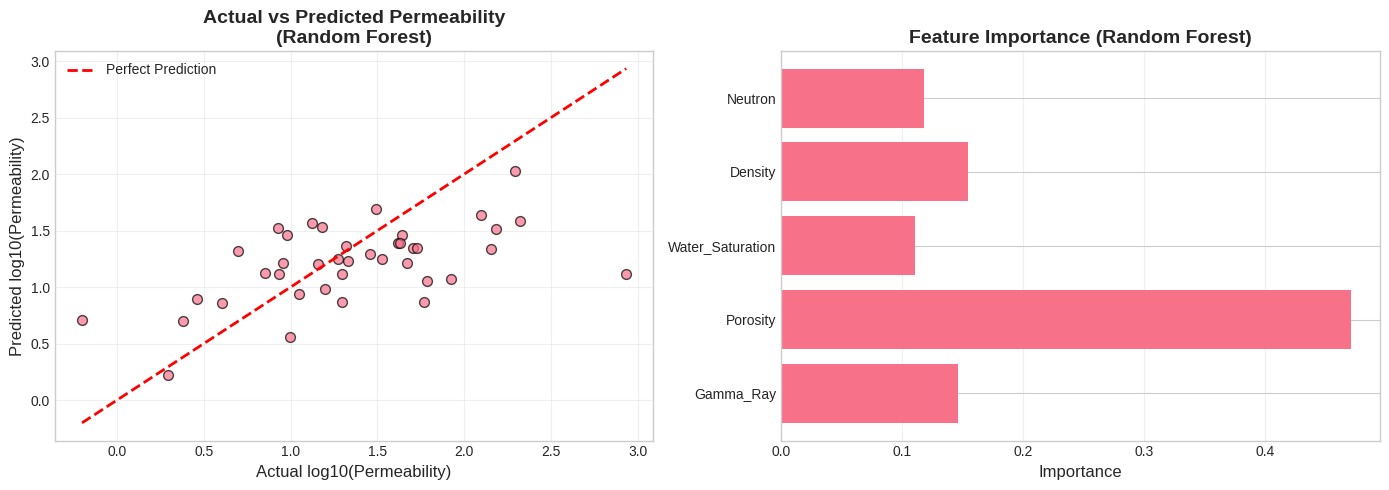

✓ Saved: ml_01_regression_results.png

SECTION 3: SUPERVISED LEARNING - CLASSIFICATION
Predicting Reservoir Quality (Good/Poor)

[3.1] Training Logistic Regression Model...
Logistic Regression Results:
  • Accuracy: 0.8250

Classification Report:
              precision    recall  f1-score   support

        Good       0.75      0.33      0.46         9
        Poor       0.83      0.97      0.90        31

    accuracy                           0.82        40
   macro avg       0.79      0.65      0.68        40
weighted avg       0.81      0.82      0.80        40


[3.2] Training Random Forest Classifier...
Random Forest Results:
  • Accuracy: 0.7500

Classification Report:
              precision    recall  f1-score   support

        Good       0.00      0.00      0.00         9
        Poor       0.77      0.97      0.86        31

    accuracy                           0.75        40
   macro avg       0.38      0.48      0.43        40
weighted avg       0.60      0.75      0.6

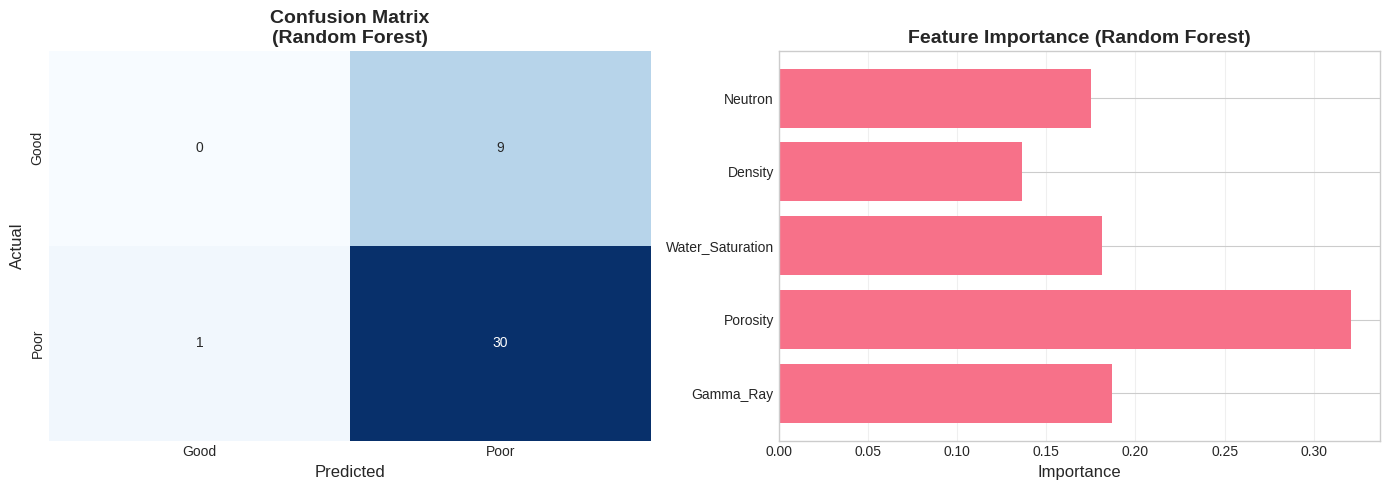

✓ Saved: ml_02_classification_results.png

SECTION 4: UNSUPERVISED LEARNING - CLUSTERING
Identifying Rock Types from Well Logs

[4.1] Training K-Means Clustering Model...
✓ K-Means clustering completed with 4 clusters

Cluster distribution:
Cluster
0    53
1    40
2    52
3    55
Name: count, dtype: int64

[4.2] Cluster Characteristics...
Cluster mean values:
         Gamma_Ray   Porosity   Density    Neutron
Cluster                                           
0        41.719199  15.933178  2.368536  28.790188
1        79.226042  16.380067  2.268778  13.439448
2        73.594886  24.761665  2.296184  23.295202
3        76.800505  16.656461  2.759508  24.621550

[4.3] Visualizing Clustering Results...


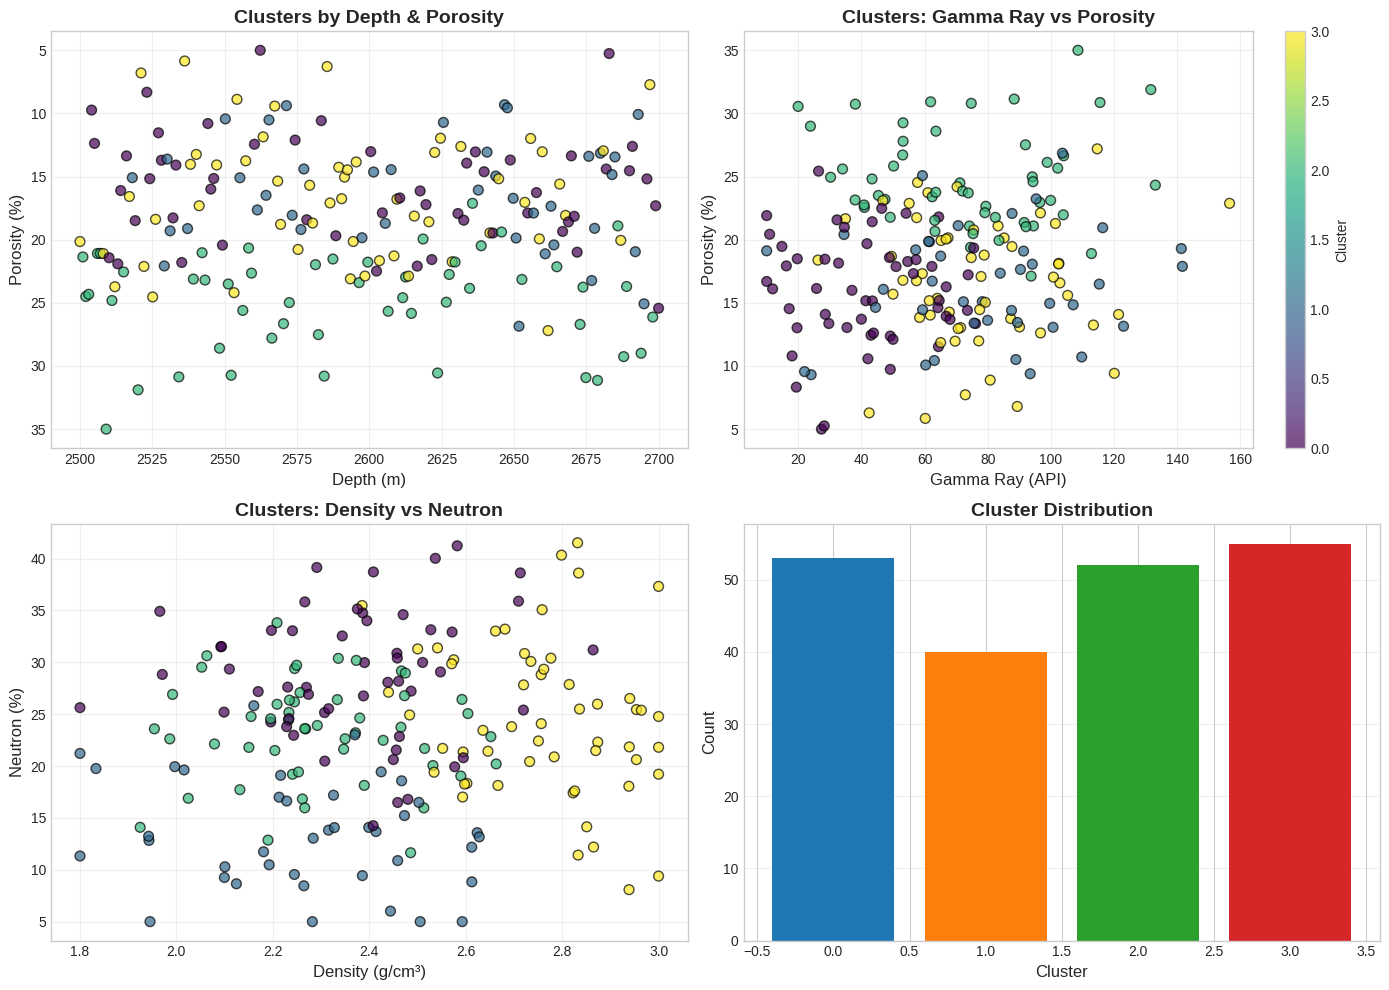

✓ Saved: ml_03_clustering_results.png

SECTION 5: MODEL COMPARISON & SELECTION

[5.1] Model Comparison Summary...
              Model           Task      Score RMSE/Acc
  Linear Regression     Regression  R²=0.2630   0.5272
Random Forest (Reg)     Regression  R²=0.2563   0.5296
Logistic Regression Classification Acc=0.8250   0.1750
Random Forest (Clf) Classification Acc=0.7500   0.2500

[5.2] Best Model Selection...
✓ Best Regression Model: Linear Regression (R²=0.2630)
✓ Best Classification Model: Logistic Regression (Acc=0.8250)

SECTION 6: PREDICT ON NEW WELL DATA

[6.1] Creating Sample New Well Data...
New well data:
   Gamma_Ray  Porosity  Water_Saturation  Density  Neutron
0         45        22                30      2.3       20
1         85        12                55      2.6       30
2         55        25                25      2.2       18
3         95        10                70      2.7       35

[6.2] Making Predictions on New Data...

Predictions:

Sample 1:
  • Reserv

In [ ]:
# ============================================
# MACHINE LEARNING TUTORIAL FOR BEGINNERS
# Petrophysics & Geoscience Applications
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("=" * 70)
print("MACHINE LEARNING TUTORIAL FOR BEGINNERS")
print("Petrophysics & Geoscience Applications")
print("=" * 70)

# ============================================
# STEP 0: CREATE SAMPLE PETROPHYSICAL DATA
# ============================================
print("\n[STEP 0] Creating Sample Petrophysical Dataset...")
print("-" * 70)

np.random.seed(42)
n_samples = 200

# Generate realistic well log data
data = {
    'Depth_m': np.linspace(2500, 2700, n_samples),
    'Gamma_Ray': np.random.normal(65, 25, n_samples).clip(20, 150),
    'Porosity': np.random.normal(18, 6, n_samples).clip(5, 35),
    'Permeability': np.random.lognormal(3, 1.2, n_samples),
    'Water_Saturation': np.random.normal(40, 18, n_samples).clip(15, 95),
    'Density': np.random.normal(2.4, 0.3, n_samples).clip(1.8, 3.0),
    'Neutron': np.random.normal(22, 8, n_samples).clip(5, 45),
    'Formation': np.random.choice(
        ['Sandstone', 'Shale', 'Limestone', 'Dolomite'],
        n_samples,
        p=[0.4, 0.3, 0.2, 0.1]
    )
}

# Add realistic correlations
data['Permeability'] = data['Permeability'] * (data['Porosity'] / 18) ** 2.5
data['Gamma_Ray'] = np.where(
    data['Formation'] == 'Shale',
    data['Gamma_Ray'] + 30,
    data['Gamma_Ray'] - 10
)

df = pd.DataFrame(data)

# Create target variable for classification (Reservoir Quality)
df['Reservoir_Quality'] = np.where(
    (df['Porosity'] > 15) & (df['Permeability'] > 50),
    'Good', 'Poor'
)

print(f"✓ Dataset created with {len(df)} samples")
print(f"✓ Features: {list(df.columns[:-1])}")
print(f"✓ Target (Classification): Reservoir_Quality")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nClass distribution:")
print(df['Reservoir_Quality'].value_counts())

# ============================================
# SECTION 1: DATA PREPARATION FOR ML
# ============================================
print("\n" + "=" * 70)
print("SECTION 1: DATA PREPARATION FOR MACHINE LEARNING")
print("=" * 70)

# --------------------------------------------
# 1.1 Check for Missing Values
# --------------------------------------------
print("\n[1.1] Checking for Missing Values...")

missing = df.isnull().sum()
print(f"Missing values per column:\n{missing}")
print(f"Total missing: {missing.sum()}")

# Fill missing values if any
df = df.fillna(df.mean(numeric_only=True))
print("✓ Missing values handled")

# --------------------------------------------
# 1.2 Encode Categorical Variables
# --------------------------------------------
print("\n[1.2] Encoding Categorical Variables...")

# Encode Formation names
le_formation = LabelEncoder()
df['Formation_Encoded'] = le_formation.fit_transform(df['Formation'])
print(f"Formation mapping: {dict(zip(le_formation.classes_, le_formation.transform(le_formation.classes_)))}")

# Encode Target variable
le_target = LabelEncoder()
df['Quality_Encoded'] = le_target.fit_transform(df['Reservoir_Quality'])
print(f"Quality mapping: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")

# --------------------------------------------
# 1.3 Select Features for ML
# --------------------------------------------
print("\n[1.3] Selecting Features for ML Models...")

# Features for regression (predict permeability)
feature_cols_reg = ['Gamma_Ray', 'Porosity', 'Water_Saturation', 'Density', 'Neutron']
X_reg = df[feature_cols_reg]
y_reg = np.log10(df['Permeability'])  # Log transform for better distribution

# Features for classification (predict reservoir quality)
feature_cols_clf = ['Gamma_Ray', 'Porosity', 'Water_Saturation', 'Density', 'Neutron']
X_clf = df[feature_cols_clf]
y_clf = df['Quality_Encoded']

print(f"Regression features: {feature_cols_reg}")
print(f"Regression target: Permeability (log10)")
print(f"\nClassification features: {feature_cols_clf}")
print(f"Classification target: Reservoir_Quality")

# --------------------------------------------
# 1.4 Split Data: Train & Test
# --------------------------------------------
print("\n[1.4] Splitting Data into Train & Test Sets...")

# Regression split
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
print(f"Regression - Train: {len(X_reg_train)}, Test: {len(X_reg_test)}")

# Classification split
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)
print(f"Classification - Train: {len(X_clf_train)}, Test: {len(X_clf_test)}")

# --------------------------------------------
# 1.5 Feature Scaling
# --------------------------------------------
print("\n[1.5] Scaling Features (Standardization)...")

scaler_reg = StandardScaler()
X_reg_train_scaled = scaler_reg.fit_transform(X_reg_train)
X_reg_test_scaled = scaler_reg.transform(X_reg_test)

scaler_clf = StandardScaler()
X_clf_train_scaled = scaler_clf.fit_transform(X_clf_train)
X_clf_test_scaled = scaler_clf.transform(X_clf_test)

print("✓ Features scaled (mean=0, std=1)")

# ============================================
# SECTION 2: SUPERVISED LEARNING - REGRESSION
# ============================================
print("\n" + "=" * 70)
print("SECTION 2: SUPERVISED LEARNING - REGRESSION")
print("Predicting Permeability from Well Logs")
print("=" * 70)

# --------------------------------------------
# 2.1 Linear Regression
# --------------------------------------------
print("\n[2.1] Training Linear Regression Model...")

lr_model = LinearRegression()
lr_model.fit(X_reg_train_scaled, y_reg_train)

# Predictions
y_reg_pred_lr = lr_model.predict(X_reg_test_scaled)

# Evaluate
lr_mse = mean_squared_error(y_reg_test, y_reg_pred_lr)
lr_r2 = r2_score(y_reg_test, y_reg_pred_lr)
lr_rmse = np.sqrt(lr_mse)

print(f"Linear Regression Results:")
print(f"  • R² Score: {lr_r2:.4f}")
print(f"  • RMSE: {lr_rmse:.4f}")
print(f"  • MSE: {lr_mse:.4f}")

# Feature importance (coefficients)
print(f"\nFeature Coefficients:")
for feat, coef in zip(feature_cols_reg, lr_model.coef_):
    print(f"  {feat}: {coef:.4f}")

# --------------------------------------------
# 2.2 Random Forest Regressor
# --------------------------------------------
print("\n[2.2] Training Random Forest Regressor...")

rf_reg_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg_model.fit(X_reg_train_scaled, y_reg_train)

# Predictions
y_reg_pred_rf = rf_reg_model.predict(X_reg_test_scaled)

# Evaluate
rf_mse = mean_squared_error(y_reg_test, y_reg_pred_rf)
rf_r2 = r2_score(y_reg_test, y_reg_pred_rf)
rf_rmse = np.sqrt(rf_mse)

print(f"Random Forest Results:")
print(f"  • R² Score: {rf_r2:.4f}")
print(f"  • RMSE: {rf_rmse:.4f}")
print(f"  • MSE: {rf_mse:.4f}")

# Feature importance
print(f"\nFeature Importance:")
for feat, imp in zip(feature_cols_reg, rf_reg_model.feature_importances_):
    print(f"  {feat}: {imp:.4f}")

# --------------------------------------------
# 2.3 Cross-Validation
# --------------------------------------------
print("\n[2.3] Cross-Validation (5-fold)...")

cv_scores = cross_val_score(rf_reg_model, X_reg_train_scaled, y_reg_train,
                            cv=5, scoring='r2')
print(f"Cross-Validation R² Scores: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# --------------------------------------------
# 2.4 Visualization - Regression Results
# --------------------------------------------
print("\n[2.4] Visualizing Regression Results...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_reg_test, y_reg_pred_rf, alpha=0.7, s=50, edgecolors='black')
axes[0].plot([y_reg_test.min(), y_reg_test.max()],
             [y_reg_test.min(), y_reg_test.max()],
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual log10(Permeability)', fontsize=12)
axes[0].set_ylabel('Predicted log10(Permeability)', fontsize=12)
axes[0].set_title('Actual vs Predicted Permeability\n(Random Forest)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Feature Importance
axes[1].barh(feature_cols_reg, rf_reg_model.feature_importances_)
axes[1].set_xlabel('Importance', fontsize=12)
axes[1].set_title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('ml_01_regression_results.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: ml_01_regression_results.png")

# ============================================
# SECTION 3: SUPERVISED LEARNING - CLASSIFICATION
# ============================================
print("\n" + "=" * 70)
print("SECTION 3: SUPERVISED LEARNING - CLASSIFICATION")
print("Predicting Reservoir Quality (Good/Poor)")
print("=" * 70)

# --------------------------------------------
# 3.1 Logistic Regression
# --------------------------------------------
print("\n[3.1] Training Logistic Regression Model...")

log_clf_model = LogisticRegression(random_state=42, max_iter=1000)
log_clf_model.fit(X_clf_train_scaled, y_clf_train)

# Predictions
y_clf_pred_log = log_clf_model.predict(X_clf_test_scaled)
y_clf_prob_log = log_clf_model.predict_proba(X_clf_test_scaled)

# Evaluate
log_acc = accuracy_score(y_clf_test, y_clf_pred_log)
print(f"Logistic Regression Results:")
print(f"  • Accuracy: {log_acc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_clf_test, y_clf_pred_log,
                            target_names=le_target.classes_))

# --------------------------------------------
# 3.2 Random Forest Classifier
# --------------------------------------------
print("\n[3.2] Training Random Forest Classifier...")

rf_clf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf_model.fit(X_clf_train_scaled, y_clf_train)

# Predictions
y_clf_pred_rf = rf_clf_model.predict(X_clf_test_scaled)
y_clf_prob_rf = rf_clf_model.predict_proba(X_clf_test_scaled)

# Evaluate
rf_acc = accuracy_score(y_clf_test, y_clf_pred_rf)
print(f"Random Forest Results:")
print(f"  • Accuracy: {rf_acc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_clf_test, y_clf_pred_rf,
                            target_names=le_target.classes_))

# --------------------------------------------
# 3.3 Confusion Matrix
# --------------------------------------------
print("\n[3.3] Confusion Matrix...")

cm = confusion_matrix(y_clf_test, y_clf_pred_rf)
print(f"Confusion Matrix:\n{cm}")

# --------------------------------------------
# 3.4 Visualization - Classification Results
# --------------------------------------------
print("\n[3.4] Visualizing Classification Results...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_,
            ax=axes[0], cbar=False)
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_title('Confusion Matrix\n(Random Forest)', fontsize=14, fontweight='bold')

# Feature Importance
axes[1].barh(feature_cols_clf, rf_clf_model.feature_importances_)
axes[1].set_xlabel('Importance', fontsize=12)
axes[1].set_title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('ml_02_classification_results.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: ml_02_classification_results.png")

# ============================================
# SECTION 4: UNSUPERVISED LEARNING - CLUSTERING
# ============================================
print("\n" + "=" * 70)
print("SECTION 4: UNSUPERVISED LEARNING - CLUSTERING")
print("Identifying Rock Types from Well Logs")
print("=" * 70)

# --------------------------------------------
# 4.1 K-Means Clustering
# --------------------------------------------
print("\n[4.1] Training K-Means Clustering Model...")

# Prepare data for clustering (use well log features)
cluster_features = ['Gamma_Ray', 'Porosity', 'Density', 'Neutron']
X_cluster = df[cluster_features].values

# Scale features
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# Apply K-Means with 4 clusters (matching 4 formations)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_cluster_scaled)

print(f"✓ K-Means clustering completed with 4 clusters")
print(f"\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())

# --------------------------------------------
# 4.2 Analyze Cluster Characteristics
# --------------------------------------------
print("\n[4.2] Cluster Characteristics...")

cluster_stats = df.groupby('Cluster')[cluster_features].mean()
print(f"Cluster mean values:\n{cluster_stats}")

# --------------------------------------------
# 4.3 Visualization - Clustering Results
# --------------------------------------------
print("\n[4.3] Visualizing Clustering Results...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Cluster by Depth
axes[0, 0].scatter(df['Depth_m'], df['Porosity'],
                   c=df['Cluster'], cmap='viridis',
                   alpha=0.7, s=50, edgecolors='black')
axes[0, 0].set_xlabel('Depth (m)', fontsize=12)
axes[0, 0].set_ylabel('Porosity (%)', fontsize=12)
axes[0, 0].set_title('Clusters by Depth & Porosity', fontsize=14, fontweight='bold')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(True, alpha=0.3)

# Gamma Ray vs Porosity
scatter = axes[0, 1].scatter(df['Gamma_Ray'], df['Porosity'],
                             c=df['Cluster'], cmap='viridis',
                             alpha=0.7, s=50, edgecolors='black')
axes[0, 1].set_xlabel('Gamma Ray (API)', fontsize=12)
axes[0, 1].set_ylabel('Porosity (%)', fontsize=12)
axes[0, 1].set_title('Clusters: Gamma Ray vs Porosity', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[0, 1], label='Cluster')

# Density vs Neutron (Lithology identification)
axes[1, 0].scatter(df['Density'], df['Neutron'],
                   c=df['Cluster'], cmap='viridis',
                   alpha=0.7, s=50, edgecolors='black')
axes[1, 0].set_xlabel('Density (g/cm³)', fontsize=12)
axes[1, 0].set_ylabel('Neutron (%)', fontsize=12)
axes[1, 0].set_title('Clusters: Density vs Neutron', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Cluster distribution
cluster_counts = df['Cluster'].value_counts().sort_index()
axes[1, 1].bar(cluster_counts.index, cluster_counts.values,
               color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[1, 1].set_xlabel('Cluster', fontsize=12)
axes[1, 1].set_ylabel('Count', fontsize=12)
axes[1, 1].set_title('Cluster Distribution', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('ml_03_clustering_results.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: ml_03_clustering_results.png")

# ============================================
# SECTION 5: MODEL COMPARISON & SELECTION
# ============================================
print("\n" + "=" * 70)
print("SECTION 5: MODEL COMPARISON & SELECTION")
print("=" * 70)

# --------------------------------------------
# 5.1 Compare All Models
# --------------------------------------------
print("\n[5.1] Model Comparison Summary...")

comparison_data = {
    'Model': ['Linear Regression', 'Random Forest (Reg)',
              'Logistic Regression', 'Random Forest (Clf)'],
    'Task': ['Regression', 'Regression', 'Classification', 'Classification'],
    'Score': [f"R²={lr_r2:.4f}", f"R²={rf_r2:.4f}",
              f"Acc={log_acc:.4f}", f"Acc={rf_acc:.4f}"],
    'RMSE/Acc': [f"{lr_rmse:.4f}", f"{rf_rmse:.4f}",
                 f"{1-log_acc:.4f}", f"{1-rf_acc:.4f}"]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# --------------------------------------------
# 5.2 Best Model Selection
# --------------------------------------------
print("\n[5.2] Best Model Selection...")

if rf_r2 > lr_r2:
    print(f"✓ Best Regression Model: Random Forest (R²={rf_r2:.4f})")
else:
    print(f"✓ Best Regression Model: Linear Regression (R²={lr_r2:.4f})")

if rf_acc > log_acc:
    print(f"✓ Best Classification Model: Random Forest (Acc={rf_acc:.4f})")
else:
    print(f"✓ Best Classification Model: Logistic Regression (Acc={log_acc:.4f})")

# ============================================
# SECTION 6: PREDICT ON NEW DATA
# ============================================
print("\n" + "=" * 70)
print("SECTION 6: PREDICT ON NEW WELL DATA")
print("=" * 70)

# --------------------------------------------
# 6.1 Create New Well Data
# --------------------------------------------
print("\n[6.1] Creating Sample New Well Data...")

new_well_data = {
    'Gamma_Ray': [45, 85, 55, 95],
    'Porosity': [22, 12, 25, 10],
    'Water_Saturation': [30, 55, 25, 70],
    'Density': [2.3, 2.6, 2.2, 2.7],
    'Neutron': [20, 30, 18, 35]
}

new_well_df = pd.DataFrame(new_well_data)
print(f"New well data:\n{new_well_df}")

# --------------------------------------------
# 6.2 Make Predictions
# --------------------------------------------
print("\n[6.2] Making Predictions on New Data...")

# Scale new data
new_well_scaled = scaler_clf.transform(new_well_df)

# Predict reservoir quality
quality_pred = rf_clf_model.predict(new_well_scaled)
quality_prob = rf_clf_model.predict_proba(new_well_scaled)

# Predict permeability
new_well_reg_scaled = scaler_reg.transform(new_well_df)
perm_pred_log = rf_reg_model.predict(new_well_reg_scaled)
perm_pred = 10 ** perm_pred_log  # Convert back from log10

print(f"\nPredictions:")
for i in range(len(new_well_df)):
    print(f"\nSample {i+1}:")
    print(f"  • Reservoir Quality: {le_target.inverse_transform([quality_pred[i]])[0]}")
    print(f"  • Quality Probability: {quality_prob[i].max():.2%}")
    print(f"  • Predicted Permeability: {perm_pred[i]:.2f} mD")

# ============================================
# SECTION 7: SAVE MODELS & RESULTS
# ============================================
print("\n" + "=" * 70)
print("SECTION 7: SAVE MODELS & RESULTS")
print("=" * 70)

# Save processed data
df.to_csv('ml_petrophysics_processed.csv', index=False)
print("✓ Saved: ml_petrophysics_processed.csv")

# Save models (using pickle)
import pickle

with open('ml_rf_regressor.pkl', 'wb') as f:
    pickle.dump(rf_reg_model, f)
print("✓ Saved: ml_rf_regressor.pkl")

with open('ml_rf_classifier.pkl', 'wb') as f:
    pickle.dump(rf_clf_model, f)
print("✓ Saved: ml_rf_classifier.pkl")

with open('ml_scalers.pkl', 'wb') as f:
    pickle.dump({'reg': scaler_reg, 'clf': scaler_clf, 'cluster': scaler_cluster}, f)
print("✓ Saved: ml_scalers.pkl")

# ============================================
# SECTION 8: QUICK START TEMPLATE
# ============================================
print("\n" + "=" * 70)
print("SECTION 8: QUICK START TEMPLATE FOR YOUR DATA")
print("=" * 70)

template_code = '''
# ============================================
# QUICK START: ML ON YOUR PETROPHYSICAL DATA
# ============================================

import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# 1. LOAD YOUR DATA
df = pd.read_csv('your_well_data.csv')

# 2. SELECT FEATURES & TARGET
features = ['Gamma_Ray', 'Porosity', 'Density', 'Neutron']
X = df[features]
y = df['Permeability']  # or your target variable

# 3. SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. TRAIN MODEL
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. EVALUATE
y_pred = model.predict(X_test)
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")

# 6. FEATURE IMPORTANCE
for feat, imp in zip(features, model.feature_importances_):
    print(f"{feat}: {imp:.4f}")

# 7. PREDICT ON NEW DATA
new_data = pd.DataFrame({
    'Gamma_Ray': [50],
    'Porosity': [20],
    'Density': [2.4],
    'Neutron': [22]
})
prediction = model.predict(new_data)
print(f"Predicted Permeability: {prediction[0]:.2f} mD")
'''

print(template_code)

# ============================================
# FINAL SUMMARY
# ============================================
print("\n" + "=" * 70)
print("TUTORIAL COMPLETED!")
print("=" * 70)

print("\n✅ What You Learned:")
print("  1. Data preparation for ML (encoding, scaling, splitting)")
print("  2. Regression: Predict permeability from well logs")
print("  3. Classification: Predict reservoir quality (Good/Poor)")
print("  4. Clustering: Identify rock types without labels")
print("  5. Model evaluation (R², Accuracy, Confusion Matrix)")
print("  6. Feature importance interpretation")
print("  7. Cross-validation for robust evaluation")
print("  8. Predict on new well data")
print("  9. Save models for future use")

print("\n📁 Files Created:")
output_files = [
    'ml_petrophysics_processed.csv',
    'ml_rf_regressor.pkl',
    'ml_rf_classifier.pkl',
    'ml_scalers.pkl',
    'ml_01_regression_results.png',
    'ml_02_classification_results.png',
    'ml_03_clustering_results.png'
]
for f in output_files:
    print(f"  • {f}")

print("\n🔑 Key ML Concepts for Petrophysics:")
print("  • Regression → Predict continuous values (permeability, porosity)")
print("  • Classification → Predict categories (reservoir quality, lithology)")
print("  • Clustering → Find patterns without labels (rock typing)")
print("  • Feature Importance → Understand which logs matter most")
print("  • Cross-Validation → Ensure model works on unseen data")

print("\n🎯 Next Steps:")
print("  1. Replace sample data with your well log CSV")
print("  2. Adjust features based on your available logs")
print("  3. Try different models (XGBoost, SVM, Neural Networks)")
print("  4. Add more evaluation metrics (MAE, Precision, Recall)")
print("  5. Deploy models for real-time well log interpretation")

print("\n" + "=" * 70)
print("HAPPY MACHINE LEARNING WITH PETROPHYSICAL DATA! 🛢️📊")
print("=" * 70)